# Controller pipeline

Calibrate -> noise -> record -> view -> fly. Run setup, then any stage on its own.
Each stage's detail is in its own `theory.md`; this is only the driver.

In [6]:
import sys
from pathlib import Path

sys.path[:0] = [str(Path.cwd() / d) for d in ("calib", "camera", "pose", "viz", "control")]
import identify

for d in identify.connected():
    print(f"{d.name:32s} {d.unique_id}")
print("ELP indices:", identify.elp_indices())
# Printed, deliberately not saved: the device list moves, so a captured variable goes
# stale. capture() and record() resolve it themselves at the moment they open.

Global Shutter Camera            0x112000032e49281
Global Shutter Camera            0x111000032e49281
FaceTime HD Camera               47B4B64B-7067-4B9C-AD2B-AE273A71F4B5
Kevin’s iPhone Camera            FC022C17-ACC0-48CA-A8B2-38D100000001
ELP indices: [0, 1]


## 1. Calibrate

Board -> intrinsics -> extrinsics -> `calib/stereo_rig.json`, which also records
*which* two cameras these were, so later stages can find them again.

In [7]:
from calibrate import PAIR_DIR, SPEC, run_calibration
from capture import capture
from plots import undistort_figure
from results import write_results

capture(PAIR_DIR, spec=SPEC)                 # reuses the bag; override=True re-shoots, SPACE pauses
# capture(PAIR_DIR, override=True)  # reuses the bag; override=True re-shoots, SPACE pauses
                       # straight edges should straighten

reusing /Users/meli/Desktop/Kevin/UCB/FlyingRobotsActiveControl/ESP32_PMW/results/stereo_calibration/pairs: 18 pair(s), [76, 64] solo, board 9x6_6mm, shot 2026-08-29T21:20:31+00:00
  capture(..., override=True) re-shoots it, append=True adds to it


PosixPath('/Users/meli/Desktop/Kevin/UCB/FlyingRobotsActiveControl/ESP32_PMW/results/stereo_calibration/pairs')

camera A: 94 usable views, 31.6 corners mean
camera B: 82 usable views, 29.9 corners mean
image size (1280, 800)

camera A: 91 views, RMS 0.2948 px, worst view 0.6976 px, 3 over 60 deg)
  fx=2753.63 fy=2750.42 cx=672.89 cy=386.14
  +/-  1.75      1.98      3.52     2.16   (1 sigma)
  dist [-3.08982e-01 -7.90162e-01 -1.91040e-03  1.15198e-03  1.16399e+01]
  incidence 11.5-59.8 deg, orientation spread 24.4 deg

camera B: 78 views, RMS 0.3400 px, worst view 0.7188 px, 4 over 60 deg)
  fx=2659.10 fy=2661.76 cx=518.91 cy=354.33
  +/-  2.11      2.52      4.73     2.61   (1 sigma)
  dist [-3.30220e-01  4.04464e-01  3.68788e-04  1.89014e-03 -3.20483e+00]
  incidence 15.9-59.3 deg, orientation spread 22.2 deg

15 usable pairs, 3 rejected
  reject pair_014: incidence 21/62 deg
  reject pair_015: incidence 61/29 deg
  reject pair_016: incidence 65/18 deg
seed from 15 pairs: baseline 184.72 mm
  pair-to-pair spread: rotation 0.064 deg median / 0.449 worst, translation 0.127 mm median / 1.020 wors

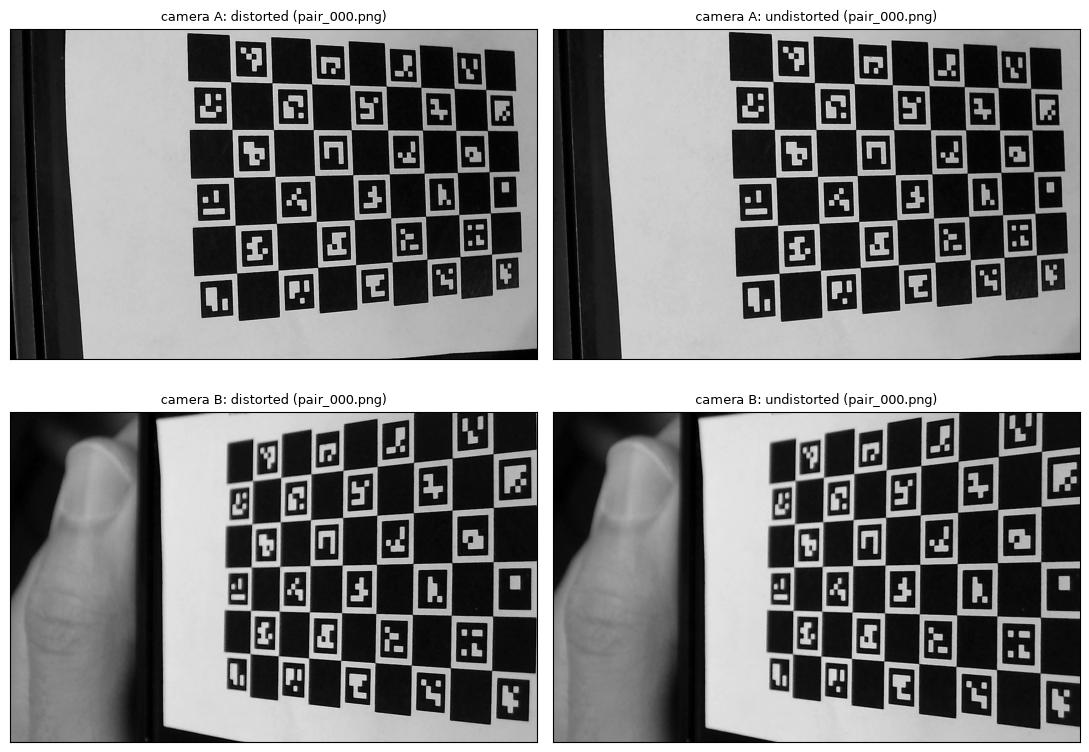

In [8]:
cal = run_calibration(SPEC, PAIR_DIR)
write_results(cal, SPEC) if cal["passed"] else print("gate failed, nothing written")
undistort_figure(cal) 

## 2. Static noise

How much the pose scatters when the robot is *not* moving -- that scatter is the
measurement noise. Artifact is `pose/noise_model.json`; everything downstream loads
it on its own.

In [9]:
import noise

# print(noise.NoiseModel.load().summary())     # what is loaded right now

# Re-record. Clamp the robot and leave the coils off: this measures the scatter around
# a truth that is not moving, so anything that really moves it is measured as noise.
# Returns at once and puts a preview + buttons below: aim until BOTH views lock an
# ellipse, press "Shoot station", move the robot to a new height, repeat. Three or four
# heights, because sigma_depth = frac * z and one height cannot separate frac from a
# constant. It writes noise_model.json on the last station.

# session = noise.record_live(stations=4)
# print(session.summary())                   # the report, once it says done


## 3. Record

Stereo mp4 per flight, each take in its own dated folder.

In [10]:
from record import DEFAULT_DIR, latest_flight, record

# Preview renders below the cell. Starting/stopping a take needs SPACE, which a cell
# has no way to send, so shoot flights from a terminal:
#   uv run python controller/camera/record.py
# record(DEFAULT_DIR)                        # preview only from here; interrupt to stop


## 4. Visualise

5-DOF pose estimation in viser. The datum puts the rotor axis on +z and the scene
follows it; the datum line printed at startup says where up ended up.

In [ ]:
from live_viz import from_recording, from_stereo, replay
from rig import StereoRig

from_stereo(StereoRig.load().sources())      # live; interrupt to stop

# import background; background.capture_stereo()   # optional saved plate, robot out of frame;
#                                                  # the default builds one from the stream
# flight = latest_flight(DEFAULT_DIR)
# from_recording(flight, csv_out=flight / "poses.csv")   # offline, from mp4
# replay(flight / "poses.csv")                           # offline, from the CSV

noise model: measured, coils_off, 4 station(s), 2026-08-29T22:14:44+00:00
using saved background plates for A, B


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

live_viz: http://localhost:8080
live_viz: datum not set yet -- the scene re-orients once the robot holds still enough to fix one
live_viz: datum set, spread 0.41 deg -- scene re-oriented


(viser) Connection opened (0, 1 total), 76 persistent messages

## 5. Fly

Closed loop off the camera. Rehearse dry first -- the live line energises coils.

In [ ]:
import hover_controller_runner as r
from rig import StereoRig

pair = StereoRig.load().sources()             # A,B in calibrated order, whatever the indices

# 1. LINK CHECK -- real serial, coils never energised. Verifies telemetry and the pose loop.
r.fly(source="camera", camera=pair, takeoff=False, record=True, log="link_check.log")

# 2. FLIGHT -- energises the coils. Open http://localhost:8080 BEFORE arming (see below).
# r.fly(source="camera", camera=pair, takeoff=True, enable_freq_cmd=True,
#       record=True, log="hover_run.log")

#   Viser "Control" folder, in this order. Two independent keys, both start safe:
#     armed      OFF. Nothing reaches the coils until it is ticked -- not even freq.
#     mag max    0.00. Clamps lateral. Armed with mag max 0 = altitude only, no lateral.
#   So:  wait out the 30 s spin-up -> "FLIGHT at NNN Hz" -> tick `armed` (altitude loop
#   closes, robot holds z) -> raise `mag max` a little (0.05-0.1) for lateral authority.
#   x/y/z (mm) are the setpoint; z starts at 60. gain lateral/vertical scale authority.
#   `land` button = hover then land. Ctrl-C = land; Ctrl-C again = stop.
#   ONE flight per boot: reset the ESP32 to fly again.


[402421.758] -> takeoff
dry run: no firmware to ramp
[402421.759] -> throttle=80
closed loop engaged
noise model: measured, coils_off, 4 station(s), 2026-08-29T22:14:44+00:00
using saved background plates for A, B


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

live_viz: http://localhost:8080
live_viz: datum not set yet -- the scene re-orients once the robot holds still enough to fix one
live_viz: reference has 2 component(s) but axes=('x', 'y', 'z') names 3. Not drawing it -- on the wrong axis it reads as a tracking error. Pass the two controlled axes, e.g. axes=('x', 'z'), naming which world axis is vertical on this rig.
live_viz: datum set, spread 0.72 deg -- scene re-oriented


(viser) Connection opened (0, 1 total), 76 persistent messages

landing: SIGINT
[402470.175] -> hover
[402470.175] -> land
[402470.199] -> stop


(viser) Connection closed (0, 0 total)

(viser) Server stopped

done -> hover_run.log


'hover_run.log'